In [6]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

### directory with N_eff results

In [9]:
adm_results_dir = '../output/results/scan/'

### Loop over directories to find all parameter points and load results

In [12]:
mde_dirs = []
mde_mdp_dirs = []

for name in os.listdir(adm_results_dir):
    if os.path.isdir(os.path.join(adm_results_dir, name)):
        mde_dirs.append(os.path.join(adm_results_dir, name))


for md in mde_dirs:
    for name in os.listdir(md):
        if os.path.isdir(os.path.join(md, name)):
            mde_mdp_dirs.append(os.path.join(md, name))
    
    

In [40]:
N_Q = 10
num_param_points = len(mde_mdp_dirs*N_Q)

m_de = np.zeros(num_param_points)
m_dp = np.zeros(num_param_points)
charges = np.zeros(num_param_points)
N_eff = np.zeros(num_param_points)
Delta_N_eff = np.zeros(num_param_points)
Delta_N_eff_dso = np.zeros(num_param_points)

res_ind = 0

for (i, res_dir) in enumerate(mde_mdp_dirs):
    result_files = [f for f in os.listdir(res_dir) if f.endswith('.npz')]
    
    for (j, rf) in enumerate(result_files):
        result = np.load(os.path.join(res_dir, rf))

        m_de[res_ind] = result['m_de']
        m_dp[res_ind] = result['m_dp']
        charges[res_ind] = result['Q']
        N_eff[res_ind] = result['N_eff_bsm']
        Delta_N_eff[res_ind] = result['Delta_Neff']
        Delta_N_eff_dso[res_ind] = result['DNeff_dso']

        res_ind += 1

In [122]:
np.savez_compressed(
    os.path.join('../output/results/','neff_scan_result.npz'),
    m_de = m_de,
    m_dp = m_dp,
    eps = charges,
    N_eff = N_eff
)

### Plots

In [48]:
unique_mde = np.unique(m_de)

N_eff_results_dict = dict()
Delta_N_eff_interp_dict = dict()

for um_de in unique_mde:
    m_dp_um = m_dp[np.where(m_de == um_de)]

    unique_mdp = np.unique(m_dp_um)

    results_dict = dict()
    interp_dict = dict()

    for um_dp in unique_mdp:
        sel = np.where(
            (m_de == um_de)
           &(m_dp == um_dp)
        )


        
        charges_um_dp = charges[sel]
        N_eff_um_dp = N_eff[sel]
        Delta_N_eff_um_dp = Delta_N_eff[sel]
        Delta_N_eff_dso_um_dp = Delta_N_eff_dso[sel]

        sort_order = charges_um_dp.argsort()

        result_um_dp = np.array([
            charges_um_dp[sort_order], 
            N_eff_um_dp[sort_order],
            Delta_N_eff_um_dp[sort_order],
            Delta_N_eff_dso_um_dp[sort_order]
        ])

        dne_I = interp1d(
            charges_um_dp[sort_order], 
            Delta_N_eff_dso_um_dp[sort_order], 
            bounds_error=False, 
            fill_value=(Delta_N_eff_dso_um_dp[sort_order][0], Delta_N_eff_dso_um_dp[sort_order][-1])
        )

        results_dict = results_dict | {um_dp: result_um_dp}
        interp_dict = interp_dict | {um_dp: dne_I}

    N_eff_results_dict = N_eff_results_dict | {um_de: results_dict}
    Delta_N_eff_interp_dict = Delta_N_eff_interp_dict | {um_de: interp_dict}

In [55]:
N_eff_results_dict[0.1][ 0.9541]

array([[ 1.00000000e-10,  2.15443469e-10,  4.64158883e-10,
         1.00000000e-09,  2.15443469e-09,  4.64158883e-09,
         1.00000000e-08,  2.15443469e-08,  4.64158883e-08,
         1.00000000e-07],
       [ 3.00851694e+00,  2.99686954e+00,  3.11360045e+00,
         4.21463199e+00,  1.16656762e+01,  1.71652078e+01,
         1.72730122e+01,  1.75869339e+01,  1.72926634e+01,
         1.63055050e+01],
       [-1.62554912e-02, -2.79028917e-02,  8.88280202e-02,
         1.18985956e+00,  8.64090379e+00,  1.41404353e+01,
         1.42482397e+01,  1.45621615e+01,  1.42678910e+01,
         1.32807326e+01],
       [ 1.36785583e-03,  8.35004690e-03,  7.01374892e-02,
         7.48648706e-01,  5.67459759e+00,  1.06733784e+01,
         1.29701564e+01,  1.34830941e+01,  1.32423996e+01,
         1.24252097e+01]])

## Make Neff contour plot in hydrogen limit

In [133]:
masses_HL = np.zeros((len(unique_mde), N_Q))
charges_HL = np.zeros((len(unique_mde), N_Q))
N_eff_HL = np.zeros((len(unique_mde), N_Q))

for (i, m_de) in enumerate(unique_mde):
    HL_mdp_key = list(N_eff_results_dict[m_de].keys())[-1]
    charges = N_eff_results_dict[m_de][HL_mdp_key][0]
    N_eff = N_eff_results_dict[m_de][HL_mdp_key][1]

    masses_HL[i, :] = m_de
    charges_HL[i, :] = charges
    N_eff_HL[i, :] = N_eff

    
# contour_levels = np.array([2.8, 3.0, 3.2, 3.5, 3.844, 4.5, 5, 7, 12, 20])
# contour_levels = np.array([3.26, 3.5, 3.844, 4.5, 5, 7])
# contour_levels = np.array([3.0, 3.26, 3.5,])
contour_levels = 5

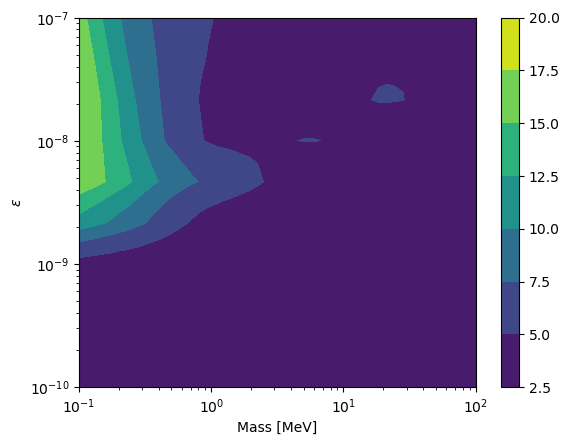

In [135]:
plt.contourf(masses_HL, charges_HL, N_eff_HL, levels=contour_levels)
plt.colorbar()

plt.xlabel('Mass [MeV]')
plt.ylabel(r'$\epsilon$')
plt.xscale('log')
plt.yscale('log')

### Make some 1-d plots for specific mass points

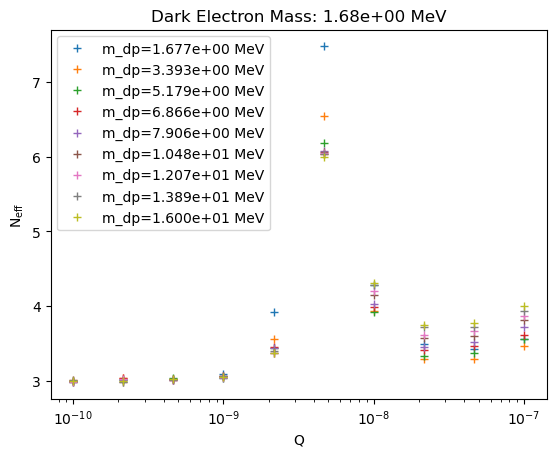

In [118]:
m_de_plot = unique_mde[20]

for m_dp in list(N_eff_results_dict[m_de_plot].keys()):
    charges_plot = N_eff_results_dict[m_de_plot][m_dp][0]
    N_eff_plot = N_eff_results_dict[m_de_plot][m_dp][1]
    
    plt.plot(charges_plot, N_eff_plot, linestyle='none', marker='+', label=f'{m_dp=:.3e} MeV')

plt.xscale('log')
plt.xlabel('Q')
plt.ylabel(r'N$_{\rm eff}$')
plt.legend()
plt.title(f'Dark Electron Mass: {m_de_plot:.2e} MeV')
plt.show()